# Lab: Agentic RAG with Self-Correction

In this notebook, we build a simple AI agent that can check its own work. 
Instead of just retrieving facts once and answering, the agent asks itself: 
"Do I have enough information?" If not, it rewrites the question and tries again — up to a limit.

This is called self-correction, and it's the core idea behind agentic RAG.

In [1]:
!pip install -qU langgraph langchain-openai langchain-huggingface pypdf requests scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Step 1: Imports

In [6]:
import os
import requests
from pypdf import PdfReader
from typing import TypedDict, List
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from sklearn.metrics.pairwise import cosine_similarity
from langgraph.graph import StateGraph, START, END

### Step 2: Configure the LLM

In [ ]:
# Set up the free LLM we will use for grading, rewriting, and generating answers
llm = ChatOpenAI(
    openai_api_key="your-api-key",
    openai_api_base="https://openrouter.ai/api/v1",
    model_name="openai/gpt-oss-20b:free",
    temperature=0.0
)
print("LLM configured successfully!")

LLM configured successfully!


### Step 3: Download PDF and Extract Text

In [8]:
# Download the PDF and extract its raw text
os.makedirs("data", exist_ok=True)

PDF_URL = "https://arxiv.org/pdf/1706.03762.pdf"
PDF_FILENAME = "data/downloaded_paper.pdf"

print(f"Downloading PDF from link: {PDF_URL}...")
response = requests.get(PDF_URL)
response.raise_for_status()

with open(PDF_FILENAME, "wb") as f:
    f.write(response.content)
print(f"PDF downloaded successfully to {PDF_FILENAME}!")

reader = PdfReader(PDF_FILENAME)
document_text = ""
for page in reader.pages:
    document_text += page.extract_text() + "\n"
    if len(document_text) >= 1500:
        document_text = document_text[:1500]
        break

print(f"Extracted {len(document_text)} characters of text.")

PDF downloaded successfully to data/downloaded_paper.pdf!
Extracted 1500 characters of text.


### Step 4: Split the Text into Chunks

In [9]:
# Configure the splitter to respect paragraphs and sentences, with a 50-character overlap
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ".", " ", ""]
)

# Split the text into a list of string chunks
knowledge_base = text_splitter.split_text(document_text)

print(f"Knowledge base ready with {len(knowledge_base)} intelligent chunks.")

Knowledge base ready with 6 intelligent chunks.


### Step 5: Load the Embedding Model and Embed Our Chunks

In [10]:
# Load the embedding model and turn every chunk into a vector
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
knowledge_vectors = embeddings.embed_documents(knowledge_base)
print("Chunks embedded successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Chunks embedded successfully!


### Step 6: Define the Agent's State

In [11]:
# This holds all the information the agent tracks as it works through the steps
class AgentState(TypedDict):
    question: str               # the current question (may get rewritten)
    retrieved_facts: List[str]  # facts found so far
    grade: str                   # YES or NO from the grading step
    retry_count: int            # how many times we've tried again
    final_answer: str           # filled in only at the end

### Step 7: Retrieve Node

In [12]:
# Find the chunks most similar in meaning to the current question
def retrieve_node(state: AgentState) -> AgentState:
    print(f"Retrieving for: '{state['question']}'")

    question_vector = embeddings.embed_query(state["question"])

    scores = cosine_similarity([question_vector], knowledge_vectors)[0]
    # Sort scores from lowest to highest, take the last 2 (highest), then reverse so the best match comes first
    top_indices = scores.argsort()[-2:][::-1]

    state["retrieved_facts"] = [knowledge_base[i] for i in top_indices]
    return state

### Step 8: Grade Node

In [20]:
# Ask the LLM whether the retrieved facts are enough to answer the question
def grade_node(state: AgentState) -> AgentState:
    facts_text = "\n".join(state["retrieved_facts"])

    # We soften the prompt so the LLM looks for ANY helpful context, not a perfect match
    prompt = f"""
    You are a grading assistant evaluating search results.
    
    Question: {state['question']}
    Retrieved facts:
    {facts_text}

    Do these facts contain ANY relevant hints, keywords, or partial information that could help answer the question?
    Reply with ONLY one word: YES or NO.
    """

    response = llm.invoke(prompt)
    raw_grade = response.content.strip().upper()
    
    # Safeguard for open-source models that might add punctuation
    if "YES" in raw_grade:
        grade = "YES"
    else:
        grade = "NO"
        
    print(f"Grade: {grade}")

    state["grade"] = grade
    return state

### Step 9: Rewrite Node

In [21]:
# Ask the LLM to write a clearer, easier-to-search version of the question
def rewrite_node(state: AgentState) -> AgentState:
    prompt = f"""
    This question did not return good search results: "{state['question']}"
    Rewrite it to be clearer and easier to search for. Reply with only the new question.
    """

    response = llm.invoke(prompt)
    new_question = response.content.strip()
    print(f"Rewritten question: {new_question}")

    state["question"] = new_question
    state["retry_count"] += 1
    return state

### Step 10: Generate Node

In [27]:
# Ask the LLM to write the final answer using the retrieved facts and explain its reasoning
def generate_node(state: AgentState) -> AgentState:
    facts_text = "\n".join(state["retrieved_facts"])

    prompt = f"""
    Answer the question using ONLY these facts:
    {facts_text}

    Question: {state['question']}
    
    Output your response in EXACTLY two sections:
    --- FINAL ANSWER ---
    [Give a short, direct answer.]

    --- EXPLAINABILITY ---
    [Briefly summarize the specific facts provided above that you used to construct this answer.]
    """

    response = llm.invoke(prompt)
    state["final_answer"] = response.content.strip()
    return state

### Step 11: Routing Function

In [28]:
# Decide whether to move forward and answer, or go back and try again
def route_after_grading(state: AgentState) -> str:
    if state["grade"] == "YES" or state["retry_count"] >= 2:
        return "generate"
    else:
        return "rewrite"

### Step 12: Build the Agent Graph

In [29]:
# Connect all the nodes together into one working graph
builder = StateGraph(AgentState)

builder.add_node("retrieve", retrieve_node)
builder.add_node("grade", grade_node)
builder.add_node("rewrite", rewrite_node)
builder.add_node("generate", generate_node)

builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "grade")
builder.add_conditional_edges("grade", route_after_grading, {
    "generate": "generate",
    "rewrite": "rewrite"
})
builder.add_edge("rewrite", "retrieve")
builder.add_edge("generate", END)

agent = builder.compile()
print("Agent graph compiled successfully!")

Agent graph compiled successfully!


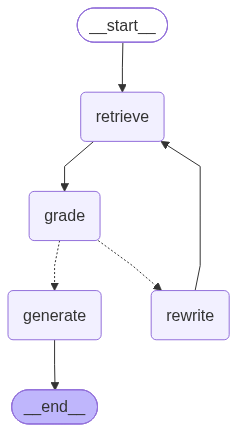

In [30]:
# Show the graph structure as an image
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

### Step 13: Run the Agent

In [ ]:
result = agent.invoke({
    "question": "How does the Transformer work?",
    "retrieved_facts": [],
    "grade": "",
    "retry_count": 0,
    "final_answer": ""
})

print(result["final_answer"])

Retrieving for: 'How does the Transformer work?'
Grade: YES

FINAL ANSWER:
--- FINAL ANSWER ---
The Transformer is a sequence‑to‑sequence model that uses only attention mechanisms to link its encoder and decoder, eliminating recurrence and convolutions.

--- EXPLAINABILITY ---
We used the fact that performing models connect the encoder and decoder through an attention mechanism, that the Transformer is a new simple architecture based solely on attention mechanisms, and that it dispenses with recurrence and convolutions, contrasting with dominant sequence transduction models that rely on complex recurrent or convolutional neural networks.
